# Edinburgh Airbnb — Price Prediction Models

Target: log1p(price), used to reduce the impact of price skew and extreme outliers.

Comparing three model families: Ridge Regression, Random Forest, and Gradient Boosting. Models are trained using sensible default parameters to focus on comparing model behaviour rather than hyperparameter optimisation. Hyperparameter tuning is left as a future improvement.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path("..").resolve()))
from src.modeling.build_star_schema import get_bathroom_column
from src.modeling.build_price_features import build_features

sns.set_style("whitegrid")
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/processed/edinburgh/listings_master.csv", low_memory=False)
df["bathroom_numeric"] = get_bathroom_column(df)

CITY_CENTRE_LAT, CITY_CENTRE_LON = 55.9486, -3.1999


def haversine_distance_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


df["distance_from_centre_km"] = haversine_distance_km(
    df["latitude"], df["longitude"], CITY_CENTRE_LAT, CITY_CENTRE_LON
)

print(f"{len(df):,} listings loaded")

4,925 listings loaded


## Feature engineering

In [2]:
X, y = build_features(df)
print(f"Feature matrix: {X.shape[0]:,} rows, {X.shape[1]} columns")
X.columns.tolist()

Dropped 8 rows with missing core fields for modeling.
Feature matrix: 4,917 rows, 40 columns


['accommodates',
 'bedrooms',
 'bathroom_numeric',
 'minimum_nights',
 'review_scores_rating',
 'host_tenure_years',
 'distance_from_centre_km',
 'entire_home_x_accommodates',
 'host_is_superhost',
 'has_no_reviews',
 'has_wifi',
 'has_kitchen',
 'has_parking',
 'has_washer',
 'has_aircon',
 'has_workspace',
 'has_elevator',
 'has_pool_or_hottub',
 'room_Hotel room',
 'room_Private room',
 'room_Shared room',
 'ptype_Hotel room',
 'ptype_Other',
 'ptype_Private room',
 'ptype_Shared room',
 'nbhd_Broughton South',
 'nbhd_Canongate, Southside and Dumbiedykes',
 'nbhd_Canonmills and New Town North',
 'nbhd_Dalry and Fountainbridge',
 'nbhd_Deans Village',
 'nbhd_Hillside and Calton Hill',
 'nbhd_Meadowbank and Abbeyhill North',
 'nbhd_Meadows and Southside',
 'nbhd_New Town East and Gayfield',
 'nbhd_New Town West',
 'nbhd_Old Town, Princes Street and Leith Street',
 'nbhd_Other',
 'nbhd_South Leith',
 'nbhd_Stockbridge',
 'nbhd_Tollcross']

## Train and compare three model families

Using 5-fold cross-validation to evaluate model performance. This reduces dependence on a single train/test split and provides out-of-fold predictions for residual analysis.

In [4]:
models = {
    # Regularize linear baseline
    "Ridge Regression": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)


def evaluate(y_true_log, y_pred_log):
    # Convern predictions back to GBP before reporting metrics
    y_true, y_pred = np.expm1(y_true_log), np.expm1(y_pred_log)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape


results = []
oof_predictions = {}

for name, model in models.items():
    preds_log = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
    mae, rmse, mape = evaluate(y.values, preds_log)
    results.append({"model": name, "MAE (£)": round(mae, 2), "RMSE (£)": round(rmse, 2), "MAPE (%)": round(mape, 1)})
    oof_predictions[name] = preds_log

results_df = pd.DataFrame(results).sort_values("RMSE (£)")
results_df

/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yasara/Documents/Projects/airbnb-analytics-platform/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/

,model,MAE (£),RMSE (£),MAPE (%)
2,Gradient Boosting,158.45,1154.06,31.6
1,Random Forest,157.94,1177.72,31.6
0,Ridge Regression,167.05,1242.01,36.0


**Model comparison.** Gradient Boosting achieved the best overall performance, with the lowest RMSE (£1,154.06) and a MAE of £158.45. Random Forest performed similarly (RMSE £1,177.72), while Ridge Regression was the weakest model (RMSE £1,242.01). The stronger performance of the tree-based models is consistent with the non-linear patterns identified in the LOWESS analysis, which linear models cannot capture as effectively. In practical terms, the best model's predictions are off by approximately £158 on average. RMSE values are inflated by a small number of extremely high-priced listings in the dataset (some exceeding £18,000), so the error metrics should be interpreted in the context of a highly skewed price distribution rather than a typical Edinburgh Airbnb listing.

## Residual analysis

Best model by RMSE: Gradient Boosting


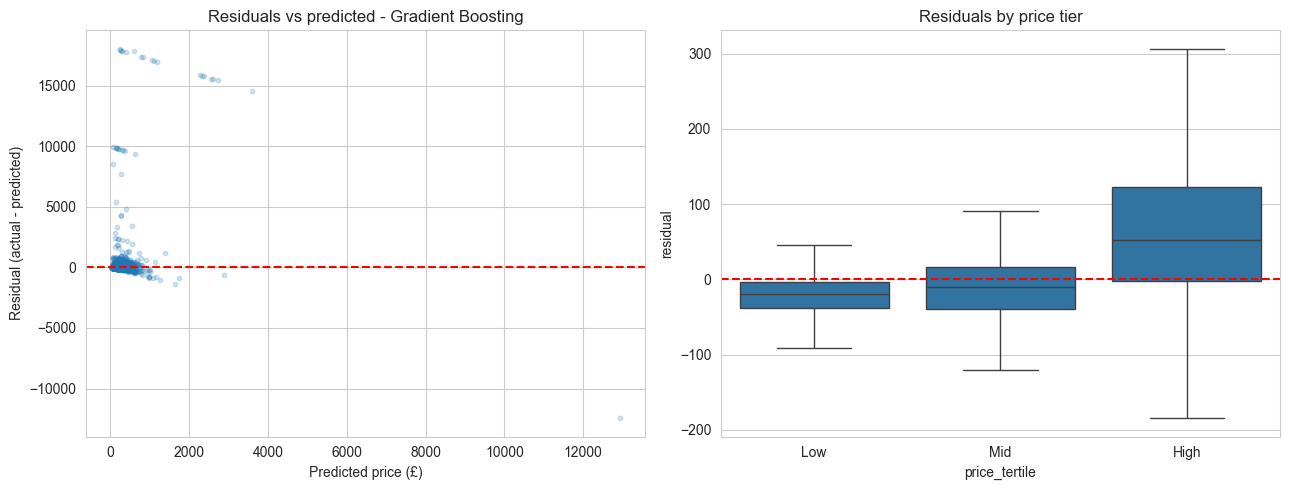

,mean,std,count
property_type_group,,,
Entire place,129.34,1340.08,3500
Hotel room,41.69,47.81,46
Other,5.56,124.91,43
Private room,33.49,393.82,1309
Shared room,122.38,249.73,19


In [6]:
best_model_name = results_df.iloc[0]["model"]
print(f"Best model by RMSE: {best_model_name}")

y_true_price = np.expm1(y.values)
y_pred_price = np.expm1(oof_predictions[best_model_name])
residuals = y_true_price - y_pred_price

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_price, residuals, alpha=0.2, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted price (£)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title(f"Residuals vs predicted - {best_model_name}")

price_tertile = pd.qcut(y_true_price, 3, labels=["Low", "Mid", "High"])
residual_df = pd.DataFrame({
    "residual": residuals,
    "price_tertile": price_tertile,
    "property_type_group": df.loc[X.index, "property_type_group"].values,
})
sns.boxplot(data=residual_df, x="price_tertile", y="residual", ax=axes[1], showfliers=False)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals by price tier")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig18_price_model_residuals.png", dpi=150)
plt.show()

residual_df.groupby("property_type_group")["residual"].agg(["mean", "std", "count"]).round(2)

**Residual interpretation.** The residual analysis suggests that prediction errors are not evenly distributed across the price range. The price-tier boxplot shows a tendency to under-predict higher-priced listings, with the high-price tier having a positive median residual and substantially greater spread than the low- and mid-price tiers. This is a common pattern in property-pricing models, as a small number of premium listings have unique characteristics that are difficult to capture using standard listing attributes.

The residuals-versus-predicted plot supports this interpretation, with the largest errors occurring among the most expensive listings. This is consistent with the extreme price outliers identified earlier, where a small number of listings exceed £18,000 per stay.

Looking at property type, Entire place listings have the largest average residual (£129.34) and by far the highest residual variability (standard deviation £1,340.08), indicating that most model error is concentrated in this segment. Private rooms and hotel rooms show substantially smaller average residuals and lower variability. This suggests that the model performs reasonably well for lower-priced accommodation types but struggles to fully capture the pricing dynamics of high-end entire-home listings.

## Explainability (SHAP)

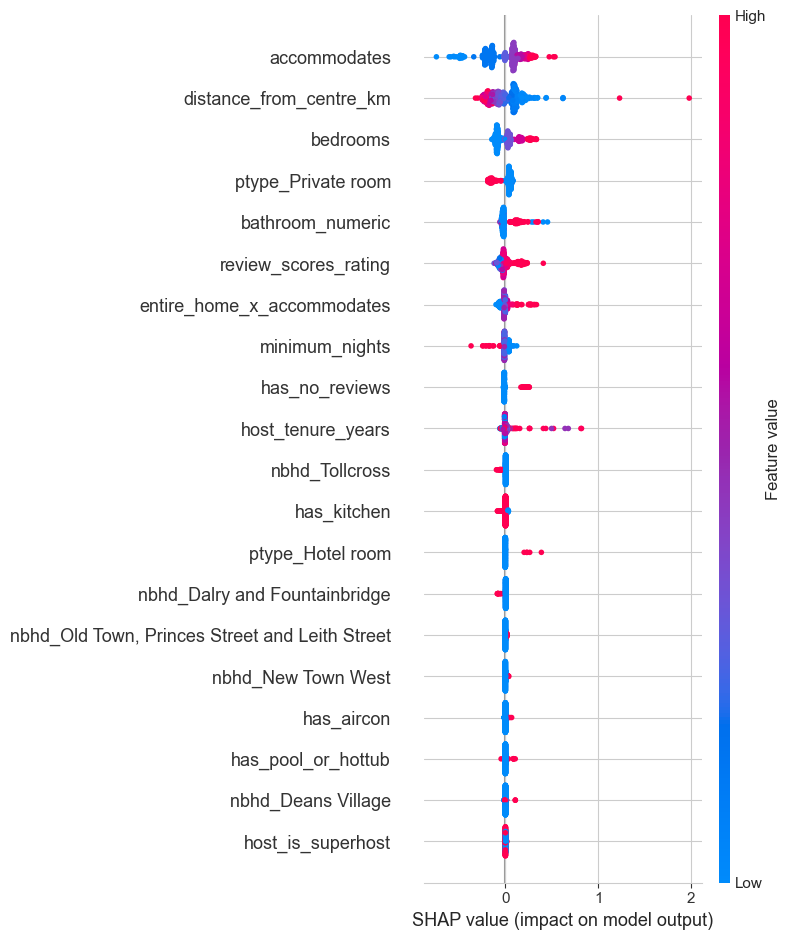

In [7]:
if "Ridge" in best_model_name:
    ridge_pipeline = models[best_model_name].fit(X, y)
    coefs = pd.Series(
        ridge_pipeline.named_steps["ridge"].coef_, index=X.columns
    ).sort_values(key=abs, ascending=False)
    print("Ridge came out ahead - showing standardized coefficients instead of SHAP:")
    print(coefs.head(10))
else:
    best_model = models[best_model_name]
    best_model.fit(X, y)

    sample = X.sample(500, random_state=42)
    explainer = shap.Explainer(best_model, sample)
    shap_values = explainer(sample)

    shap.summary_plot(shap_values, sample, show=False)
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/fig19_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

**SHAP interpretation.** The SHAP analysis identifies **accommodates** as the strongest driver of price, followed by **distance_from_centre_km**, **bedrooms**, **property type**, and **bathroom count**. This broadly agrees with the OLS regression and correlation analysis, where capacity and property size consistently emerged as key pricing factors.

One notable difference is **distance_from_centre_km**. Its linear correlation with price was close to zero, yet it ranks highly in SHAP. This supports the non-linear relationship suggested by the LOWESS analysis and demonstrates the advantage of tree-based models in capturing patterns that linear methods miss.

**Summary.** Gradient Boosting was the best-performing model, achieving the lowest RMSE (£1,154) and a mean absolute error of approximately £158 per listing. Residual analysis showed that the model performs less accurately for very expensive listings, tending to under-predict the highest-priced properties and producing larger errors for entire-home listings than for other property types. SHAP confirmed that accommodates, bedrooms, bathrooms, property type, and distance from the city centre are among the most important drivers of price. Compared with the OLS model from Step 12 (R² = 0.408), the tree-based models captured additional non-linear relationships, providing a modest but consistent improvement in predictive performance.